In [2]:
import pandas as pd

In [3]:
# Load the dataset
sales = pd.read_csv('../data/sales_train_evaluation.csv')
calendar = pd.read_csv('../data/calendar.csv')
prices = pd.read_csv('../data/sell_prices.csv')

print(sales.shape)
sales.head()

(30490, 1947)


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


In [4]:
sales.columns

Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1',
       'd_2', 'd_3', 'd_4',
       ...
       'd_1932', 'd_1933', 'd_1934', 'd_1935', 'd_1936', 'd_1937', 'd_1938',
       'd_1939', 'd_1940', 'd_1941'],
      dtype='str', length=1947)

In [5]:
print(sales['store_id'].unique())
print(sales['cat_id'].unique())

<StringArray>
['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2',
 'WI_3']
Length: 10, dtype: str
<StringArray>
['HOBBIES', 'HOUSEHOLD', 'FOODS']
Length: 3, dtype: str


In [6]:
# we can see there are 10 different stores! 
# so, since these are big datasets, maybe we can start with one store first..

In [7]:
# Row count per store, across ALL stores to choose the biggest one among them
store_counts = sales['store_id'].value_counts().sort_values(ascending=False)
print(store_counts)

store_id
CA_1    3049
CA_2    3049
CA_3    3049
CA_4    3049
TX_1    3049
TX_2    3049
TX_3    3049
WI_1    3049
WI_2    3049
WI_3    3049
Name: count, dtype: int64


In [9]:
# Filter to CA_1 only
ca1 = sales[sales['store_id'] == 'CA_1'].copy()
print(ca1.shape)

# Identify id columns vs day columns
id_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
day_cols = [c for c in ca1.columns if c.startswith('d_')]

print(f"Number of id columns: {len(id_cols)}")
print(f"Number of day columns: {len(day_cols)}")

(3049, 1947)
Number of id columns: 6
Number of day columns: 1941


In [10]:
# Filter to FOODS category within CA_1
ca1_foods = ca1[ca1['cat_id'] == 'FOODS'].copy()
print(ca1_foods.shape)

# Melt to long format
id_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
day_cols = [c for c in ca1_foods.columns if c.startswith('d_')]

ca1_foods_long = ca1_foods.melt(
    id_vars=id_cols,
    value_vars=day_cols,
    var_name='d',
    value_name='sales'
)

print(ca1_foods_long.shape)

# Now merge in calendar
ca1_foods_long = ca1_foods_long.merge(calendar, on='d', how='left')
print(ca1_foods_long.shape)
ca1_foods_long.head()

(1437, 1947)
(2789217, 8)
(2789217, 21)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
1,FOODS_1_002_CA_1_evaluation,FOODS_1_002,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
2,FOODS_1_003_CA_1_evaluation,FOODS_1_003,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
3,FOODS_1_004_CA_1_evaluation,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
4,FOODS_1_005_CA_1_evaluation,FOODS_1_005,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0


In [11]:
print(prices.shape)
prices.head()

(6841121, 4)


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [12]:
# now we have only foods data
# and we can see the prices table here
# lets join them

In [13]:
ca1_foods_long = ca1_foods_long.merge(
    prices,
    on=['store_id', 'item_id', 'wm_yr_wk'],
    how='left'
)
print(ca1_foods_long.shape)
ca1_foods_long.head()

(2789217, 22)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,2.00
1,FOODS_1_002_CA_1_evaluation,FOODS_1_002,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,7.88
2,FOODS_1_003_CA_1_evaluation,FOODS_1_003,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,2.88
3,FOODS_1_004_CA_1_evaluation,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
4,FOODS_1_005_CA_1_evaluation,FOODS_1_005,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,2.94


In [14]:
print(ca1_foods_long.shape)

# How many rows have missing price?
print(ca1_foods_long['sell_price'].isna().sum())
print(ca1_foods_long['sell_price'].isna().mean())

(2789217, 22)
528976
0.18965035707153657


In [15]:
ca1_foods_long[ca1_foods_long['sell_price'].isna()]['sales'].describe()

count    528976.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: sales, dtype: float64

In [16]:
# For each item, find the first date where sell_price is NOT null (its launch date)
launch_dates = (
    ca1_foods_long[ca1_foods_long['sell_price'].notna()]
    .groupby('item_id')['date']
    .min()
    .reset_index()
    .rename(columns={'date': 'launch_date'})
)

print(launch_dates.shape)
launch_dates.head()

(1437, 2)


,item_id,launch_date
0,FOODS_1_001,2011-01-29
1,FOODS_1_002,2011-01-29
2,FOODS_1_003,2011-01-29
3,FOODS_1_004,2012-03-03
4,FOODS_1_005,2011-01-29


In [17]:
ca1_foods_long = ca1_foods_long.merge(launch_dates, on='item_id', how='left')

# Keep only rows on/after each item's own launch date
ca1_foods_trimmed = ca1_foods_long[ca1_foods_long['date'] >= ca1_foods_long['launch_date']].copy()

print(ca1_foods_long.shape)
print(ca1_foods_trimmed.shape)

(2789217, 23)
(2260241, 23)


In [18]:
# Check 1: should be 0 (or very near it) now
print(ca1_foods_trimmed['sell_price'].isna().sum())

# Check 2: pick an item that had missing prices, check its date range
sample_item = ca1_foods_long[ca1_foods_long['sell_price'].isna()]['item_id'].iloc[0]
print(sample_item)
print(ca1_foods_trimmed[ca1_foods_trimmed['item_id'] == sample_item]['date'].min())

0
FOODS_1_004
2012-03-03


In [19]:
# now we stop and focus on the important things to remember
# 1. start with the business question
#    - now that we are considering the store CA_1 and FOODS so the plan is,
#    - To help CA_1's store manager decide how much FOODS inventory to order for the next 28 days, to minimize stockouts and overstock.
# 2. understand the target variable
#    - we are basically forecasting the demand here, more sales in a particular period, means more demand. demand cannot be 
# 3. time granularity
#    - we need to decide whether to forecast per day, week, month or year
# 4. exploring the data
#    - we currently explored it and found that there are different stores and we took one from store of california and in that we are considering FOODS!
# 5. identifying the components of a time series
#    - we need to look for trends, seasonality and all. we can do that using a plot
# 6. thinking about external factors
#    - does any external factors affect the sales or not. 
# 7. choosing the right evaluation metric
# 8. creating a baseline
# 9. forecast uncertainity matters. we don't need a perfect number, we can show the range that can be possible too
# 10. Data quality is more important the model
#     - working on this! 

In [20]:
# Check for actual NaN in sales column
print("NaNs in sales:", ca1_foods_trimmed['sales'].isna().sum())

# Check for 0s in sales column  
print("Zeros in sales:", (ca1_foods_trimmed['sales'] == 0).sum())
print("Total rows:", len(ca1_foods_trimmed))

NaNs in sales: 0
Zeros in sales: 1058608
Total rows: 2260241


In [21]:
# so, m thought on checking this is because we don't have any idea if the sales 0 means, out of stock, literally sales 0
# and i thought lets check. if there is NaN, then it means, out of stock! and if there are 0s, then it is no sale
# and found that there are no NaN. that means, we never know what it exactly means. so i think we are forecasting only sales, not demand

In [22]:
# forgot a part in cleaning the dataset
# so, date datatype could be mismaching - lets fix that

ca1_foods_trimmed['date'] = pd.to_datetime(ca1_foods_trimmed['date'])

In [25]:
# lets check if there's anything else to clean

print(ca1_foods_trimmed.dtypes)

id                         str
item_id                    str
dept_id                    str
cat_id                     str
store_id                   str
state_id                   str
d                          str
sales                    int64
date            datetime64[us]
wm_yr_wk                 int64
weekday                    str
wday                     int64
month                    int64
year                     int64
event_name_1               str
event_type_1               str
event_name_2               str
event_type_2               str
snap_CA                  int64
snap_TX                  int64
snap_WI                  int64
sell_price             float64
launch_date                str
dtype: object


In [27]:
# we can see the data types. at the bottom launch date is till str! 
ca1_foods_trimmed['launch_date'] = pd.to_datetime(ca1_foods_trimmed['launch_date'])

# Dropping columns that are redundant or unnecesary for the analysis
# store_id         -  we fixed with CA_1 so no need of it anymore
# state_id         -  Likewise
# cat_id           -  we are sticking to "FOODS" so no need
# snap_TX, snap_WI - it seems the SNAP flags are for Texas/Wisconsin — so they are irrelevant to us since we're only looking at California!
# d                - no idea where this came from but i checked it is date! 
cols_to_drop = ['store_id', 'state_id', 'cat_id', 'snap_TX', 'snap_WI', 'd']
ca1_foods_trimmed = ca1_foods_trimmed.drop(columns=cols_to_drop)

print(ca1_foods_trimmed.dtypes)
print(ca1_foods_trimmed.shape)

id                         str
item_id                    str
dept_id                    str
sales                    int64
date            datetime64[us]
wm_yr_wk                 int64
weekday                    str
wday                     int64
month                    int64
year                     int64
event_name_1               str
event_type_1               str
event_name_2               str
event_type_2               str
snap_CA                  int64
sell_price             float64
launch_date     datetime64[us]
dtype: object
(2260241, 17)


In [28]:
ca1_foods_trimmed

,id,item_id,dept_id,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,sell_price,launch_date
0,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,3,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,2.00,2011-01-29
1,FOODS_1_002_CA_1_evaluation,FOODS_1_002,FOODS_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,7.88,2011-01-29
2,FOODS_1_003_CA_1_evaluation,FOODS_1_003,FOODS_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,2.88,2011-01-29
4,FOODS_1_005_CA_1_evaluation,FOODS_1_005,FOODS_1,3,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,2.94,2011-01-29
5,FOODS_1_006_CA_1_evaluation,FOODS_1_006,FOODS_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,1.97,2011-01-29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2789212,FOODS_3_823_CA_1_evaluation,FOODS_3_823,FOODS_3,2,2016-05-22,11617,Sunday,2,5,2016,NaN,NaN,NaN,NaN,0,2.98,2012-08-04
2789213,FOODS_3_824_CA_1_evaluation,FOODS_3_824,FOODS_3,0,2016-05-22,11617,Sunday,2,5,2016,NaN,NaN,NaN,NaN,0,2.48,2011-01-29
2789214,FOODS_3_825_CA_1_evaluation,FOODS_3_825,FOODS_3,1,2016-05-22,11617,Sunday,2,5,2016,NaN,NaN,NaN,NaN,0,3.98,2011-02-05
2789215,FOODS_3_826_CA_1_evaluation,FOODS_3_826,FOODS_3,1,2016-05-22,11617,Sunday,2,5,2016,NaN,NaN,NaN,NaN,0,1.28,2013-04-13


In [29]:
# ok i think weekday and wday are representing the same thing. 
# but for saturday, wday is 1, its confusing. lets check what is happening

weekday_wday_check = ca1_foods_trimmed.groupby('weekday')['wday'].apply(set)
print(weekday_wday_check)

weekday
Friday       {7}
Monday       {3}
Saturday     {1}
Sunday       {2}
Thursday     {6}
Tuesday      {4}
Wednesday    {5}
Name: wday, dtype: object


In [31]:
# confirm! saturday is 1, and friday is 7! doesn't matter why but clearly weekday is redundant, lets remove it. 
ca1_foods_trimmed = ca1_foods_trimmed.drop(columns=['weekday'])

KeyError: "['weekday'] not found in axis"

In [32]:
ca1_foods_trimmed

,id,item_id,dept_id,sales,date,wm_yr_wk,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,sell_price,launch_date
0,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,3,2011-01-29,11101,1,1,2011,NaN,NaN,NaN,NaN,0,2.00,2011-01-29
1,FOODS_1_002_CA_1_evaluation,FOODS_1_002,FOODS_1,0,2011-01-29,11101,1,1,2011,NaN,NaN,NaN,NaN,0,7.88,2011-01-29
2,FOODS_1_003_CA_1_evaluation,FOODS_1_003,FOODS_1,0,2011-01-29,11101,1,1,2011,NaN,NaN,NaN,NaN,0,2.88,2011-01-29
4,FOODS_1_005_CA_1_evaluation,FOODS_1_005,FOODS_1,3,2011-01-29,11101,1,1,2011,NaN,NaN,NaN,NaN,0,2.94,2011-01-29
5,FOODS_1_006_CA_1_evaluation,FOODS_1_006,FOODS_1,0,2011-01-29,11101,1,1,2011,NaN,NaN,NaN,NaN,0,1.97,2011-01-29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2789212,FOODS_3_823_CA_1_evaluation,FOODS_3_823,FOODS_3,2,2016-05-22,11617,2,5,2016,NaN,NaN,NaN,NaN,0,2.98,2012-08-04
2789213,FOODS_3_824_CA_1_evaluation,FOODS_3_824,FOODS_3,0,2016-05-22,11617,2,5,2016,NaN,NaN,NaN,NaN,0,2.48,2011-01-29
2789214,FOODS_3_825_CA_1_evaluation,FOODS_3_825,FOODS_3,1,2016-05-22,11617,2,5,2016,NaN,NaN,NaN,NaN,0,3.98,2011-02-05
2789215,FOODS_3_826_CA_1_evaluation,FOODS_3_826,FOODS_3,1,2016-05-22,11617,2,5,2016,NaN,NaN,NaN,NaN,0,1.28,2013-04-13


In [34]:
# now another thing thats bugging me is the NaNs in the events! I wonder why that is and also if all the rows are
# NaN. Lets check. 
event_cols = ['event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']

for col in event_cols:
    non_nan_count = ca1_foods_trimmed[col].notna().sum()
    print(f"{col}: {non_nan_count}")

event_name_1: 183712
event_type_1: 183712
event_name_2: 4551
event_type_2: 4551


In [35]:
# ok, there are some not NaN rows. Good thing. perhaps they meant any events like Super Bowl which i know very famous in US! 
# and maybe any football games? 

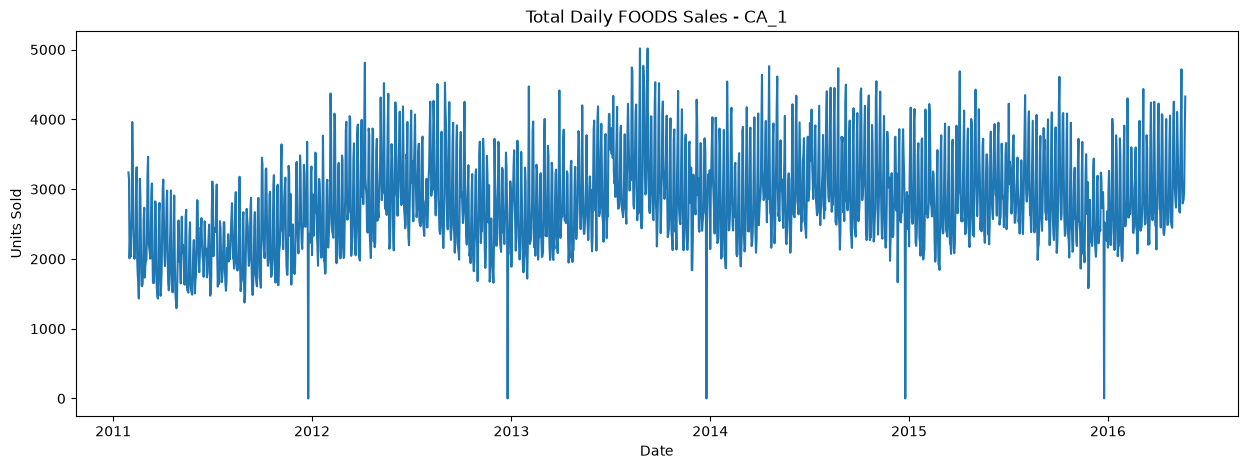

In [36]:
import matplotlib.pyplot as plt

# Total sales across all FOODS items in CA_1, per day
daily_total = ca1_foods_trimmed.groupby('date')['sales'].sum().reset_index()

plt.figure(figsize=(15, 5))
plt.plot(daily_total['date'], daily_total['sales'])
plt.title('Total Daily FOODS Sales - CA_1')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.show()

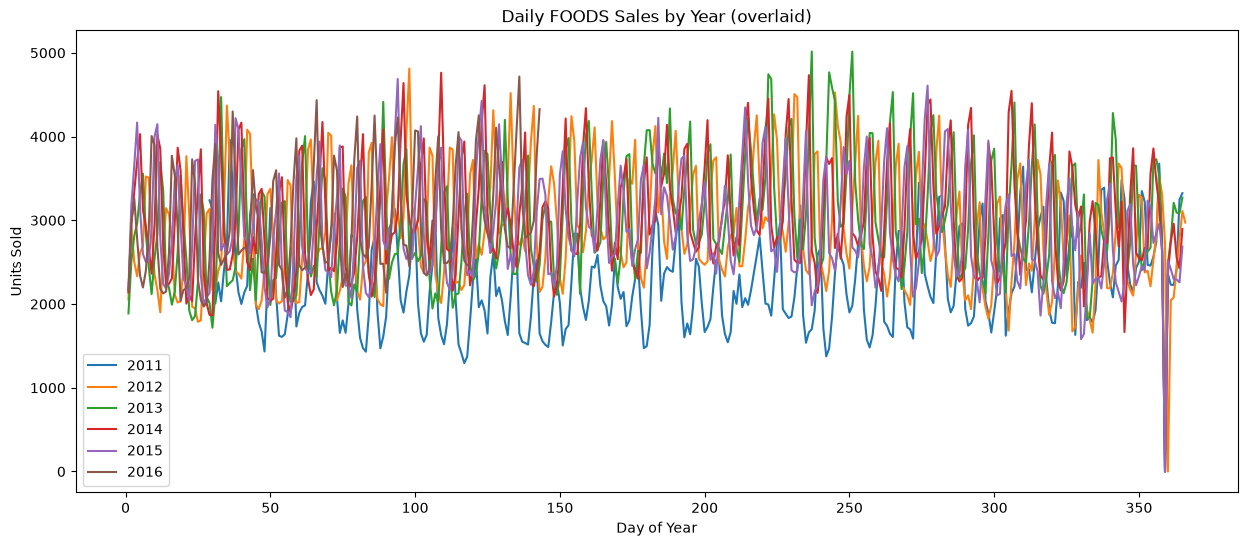

In [37]:
daily_total['year'] = daily_total['date'].dt.year

plt.figure(figsize=(15, 6))
for yr in daily_total['year'].unique():
    yearly = daily_total[daily_total['year'] == yr]
    plt.plot(yearly['date'].dt.dayofyear, yearly['sales'], label=yr)

plt.legend()
plt.title('Daily FOODS Sales by Year (overlaid)')
plt.xlabel('Day of Year')
plt.ylabel('Units Sold')
plt.show()